# Expected Permutation Importance & Reliability Decomposition

This section implements robustness and reliability checks for predictive utility and functional reliance under the fixed protocols reported in the paper.


In [1]:
from pathlib import Path
from types import SimpleNamespace
import gc, importlib, itertools, random, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

warnings.filterwarnings("ignore")

SEED = 2026
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEQ_LEN = 96
LABEL_LEN = 48
CONDITIONS = [
    ("Electricity", 192),
    ("Solar", 720),
    ("ETTh1", 720),
]

N_DONORS = 16
N_SPLITS = 50
N_TEMPORAL_BLOCKS = 4
MAX_TEST_WINDOWS = 512
RANK_K = 5

BASE_BATCH = {"Electricity": 16, "Solar": 16, "ETTh1": 64}
DONOR_CHUNK = {"Electricity": 8, "Solar": 12, "ETTh1": 16}

PROJECT_ROOT = Path("/data/code/2026_08")
BASELINE_ROOT = PROJECT_ROOT / "results_external_baselines_phase1_direct"
PREVIOUS_DIR = PROJECT_ROOT / "results_final_robustness_forecaster_specific_reliance"
PREVIOUS_PAIR_FILE = PREVIOUS_DIR / "final_pair_scores_all.csv"

OUTPUT_DIR = PROJECT_ROOT / "results_expected_permutation_importance_reliability"
CACHE_DIR = OUTPUT_DIR / "source_delta_cache"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
print("Output:", OUTPUT_DIR)

PyTorch: 2.4.1+cu121
Device: cuda
GPU: NVIDIA A100-SXM4-80GB
Output: /data/code/2026_08/results_expected_permutation_importance_reliability


In [2]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

def evenly_subsample(a, n):
    a = np.asarray(a)
    if len(a) <= n:
        return a
    idx = np.unique(np.linspace(0, len(a)-1, n, dtype=np.int64))
    return a[idx]

def safe_spearman(a, b):
    d = pd.DataFrame({"a": a, "b": b}).replace([np.inf, -np.inf], np.nan).dropna()
    if len(d) < 3 or d["a"].nunique() < 2 or d["b"].nunique() < 2:
        return np.nan
    return float(d.corr(method="spearman").iloc[0,1])

def spearman_brown(r):
    if not np.isfinite(r) or r <= -0.999999:
        return np.nan
    return float(2*r/(1+r))

def topk_set(v, ids, k):
    order = np.argsort(np.asarray(v))[::-1][:k]
    return set(np.asarray(ids)[order].tolist())

def topk_jaccard(a, b, ids, k):
    A, B = topk_set(a, ids, k), topk_set(b, ids, k)
    return len(A & B) / max(1, len(A | B))

## 1. Exact candidate pairs from the previous robustness experiment

In [3]:
if not PREVIOUS_PAIR_FILE.exists():
    raise FileNotFoundError(
        f"{PREVIOUS_PAIR_FILE}\n"
        "Run Final_Robustness_ForecasterSpecific_SourceReliance_ICLR27.ipynb first."
    )

previous_pairs = pd.read_csv(PREVIOUS_PAIR_FILE)

required = [
    "dataset","pred_len","target_channel","source_channel","pool_tag",
    "P_endpoint_mse_%","P_full_mse_%","P_full_mae_%",
    "I_Ridge_endpoint_mse_%","I_Ridge_full_mse_%","I_Ridge_full_mae_%",
    "I_MLP_endpoint_mse_%","I_MLP_full_mse_%","I_MLP_full_mae_%",
    "I_iTransformer_endpoint_mse_%","I_iTransformer_full_mse_%",
    "I_iTransformer_full_mae_%",
]
missing = [c for c in required if c not in previous_pairs.columns]
if missing:
    raise RuntimeError(f"Missing columns: {missing}")

wanted = set(CONDITIONS)
previous_pairs = previous_pairs[
    previous_pairs.apply(
        lambda r: (r["dataset"], int(r["pred_len"])) in wanted,
        axis=1,
    )
].copy()

print("Pair rows:", len(previous_pairs))
display(previous_pairs[["dataset","pred_len","target_channel","source_channel","pool_tag"]].head())

Pair rows: 393


,dataset,pred_len,target_channel,source_channel,pool_tag
0,Electricity,192,0,46,base
1,Electricity,192,0,123,base
2,Electricity,192,0,99,base
3,Electricity,192,0,270,base
4,Electricity,192,0,127,base


## 2. Time-Series-Library, datasets, and checkpoint

In [4]:
TSLIB_CANDIDATES = [
    Path("/data/Time-Series-Library"),
    Path("/data/Time-Series-Library_v2"),
    Path("/data/Time-Series-Library"),
]
TSL_ROOT = next(
    (p.resolve() for p in TSLIB_CANDIDATES if (p/"models"/"iTransformer.py").exists()),
    None,
)
if TSL_ROOT is None:
    raise FileNotFoundError("Time-Series-Library not found.")
if str(TSL_ROOT) not in sys.path:
    sys.path.insert(0, str(TSL_ROOT))
iTransformer_module = importlib.import_module("models.iTransformer")

DATASET_CANDIDATES = {
    "Electricity": [
        "/data/dataset/electricity/electricity.csv",
        "/data/dataset/ECL/electricity.csv",
        "/data/dataset/electricity.csv",
    ],
    "Solar": [
        "/data/dataset/solar/solar_AL.txt",
        "/data/dataset/Solar/solar_AL.txt",
        "/data/dataset/solar_AL.txt",
    ],
    "ETTh1": [
        "/data/dataset/ETT-small/ETTh1.csv",
        "/data/dataset/ETTh1.csv",
    ],
}
DATASET_SPECS = {
    "Electricity": {"channels":321, "freq":"h"},
    "Solar": {"channels":137, "freq":"h"},
    "ETTh1": {"channels":7, "freq":"h"},
}

def resolve_path(lst):
    for p in lst:
        if Path(p).exists():
            return Path(p).resolve()
    return None

DATASET_FILES = {d: resolve_path(v) for d,v in DATASET_CANDIDATES.items()}
for d,p in DATASET_FILES.items():
    if p is None:
        raise FileNotFoundError(f"{d}: data not found")
    print(d, "->", p)

def build_args(dataset_name, H):
    s = DATASET_SPECS[dataset_name]
    return SimpleNamespace(
        task_name="long_term_forecast", model="iTransformer",
        seq_len=SEQ_LEN, label_len=LABEL_LEN, pred_len=H,
        enc_in=s["channels"], dec_in=s["channels"], c_out=s["channels"],
        e_layers=3, d_layers=1, n_heads=8, d_model=512, d_ff=512,
        factor=3, dropout=0.1, embed="timeF", freq=s["freq"],
        activation="gelu", output_attention=False,
        class_strategy="projection", use_norm=1,
        moving_avg=25, distil=True, top_k=5, num_kernels=6,
        seasonal_patterns="Monthly", inverse=False,
    )

def load_model(dataset_name, H):
    model = iTransformer_module.Model(build_args(dataset_name,H)).float().to(DEVICE)
    ckpt = BASELINE_ROOT/"iTransformer"/dataset_name/f"H{H}"/"best_model.pt"
    if not ckpt.exists():
        raise FileNotFoundError(ckpt)
    model.load_state_dict(torch.load(ckpt, map_location="cpu"), strict=True)
    model.eval()
    return model

Electricity -> /data/dataset/electricity/electricity.csv
Solar -> /data/dataset/solar/solar_AL.txt
ETTh1 -> /data/dataset/ETT-small/ETTh1.csv


## 3. Data loading — same protocol as previous experiments

In [5]:
def load_numeric(dataset_name, path):
    path = Path(path)
    if path.suffix.lower() == ".csv":
        df = pd.read_csv(path)
        date_col = None
        for c in ["date","datetime","timestamp","time"]:
            if c in df.columns:
                date_col = c
                break
        if date_col is None and not pd.api.types.is_numeric_dtype(df[df.columns[0]]):
            date_col = df.columns[0]
        if date_col is not None:
            df = df.drop(columns=[date_col])
        x = df.select_dtypes(include=[np.number]).to_numpy(dtype=np.float32)
    else:
        try:
            x = np.loadtxt(path, delimiter=",", dtype=np.float32)
        except Exception:
            x = np.loadtxt(path, dtype=np.float32)
        if x.ndim == 1:
            x = x[:,None]
    if x.ndim != 2 or not np.isfinite(x).all():
        raise ValueError(f"{dataset_name}: invalid data {x.shape}")
    return x

def boundaries(dataset_name, T):
    if dataset_name == "ETTh1":
        tr = 12*30*24
        va = tr + 4*30*24
        te = va + 4*30*24
        return min(tr,T), min(va,T), min(te,T)
    return int(.70*T), int(.80*T), T

def load_normalized(dataset_name):
    raw = load_numeric(dataset_name, DATASET_FILES[dataset_name])
    T,C = raw.shape
    tr,va,te = boundaries(dataset_name,T)
    mu = raw[:tr].mean(0,keepdims=True)
    sd = np.maximum(raw[:tr].std(0,keepdims=True),1e-6)
    return ((raw-mu)/sd).astype(np.float32), {
        "T":T,"C":C,"train_end":tr,"val_end":va,"test_end":te
    }

def test_origins(meta,H):
    o = np.arange(max(SEQ_LEN,meta["val_end"]), meta["test_end"]-H+1, dtype=np.int64)
    return evenly_subsample(o, MAX_TEST_WINDOWS)

def make_XY(x, origins, H):
    X = np.stack([x[t-SEQ_LEN:t] for t in origins]).astype(np.float32)
    Y = np.stack([x[t:t+H] for t in origins]).astype(np.float32)
    return X,Y

## 4. Common donor mappings

In [6]:
def common_donors(N, R=N_DONORS):
    # Same donor shifts for every source. Avoid near-adjacent windows.
    min_dist = max(2, N//8)
    candidates = np.asarray(
        [s for s in range(1,N) if min(s,N-s) >= min_dist],
        dtype=np.int64,
    )
    if len(candidates) < R:
        candidates = np.arange(1,N,dtype=np.int64)

    rng = np.random.default_rng(SEED + 7919*N)
    shifts = rng.choice(candidates, size=R, replace=False)
    base = np.arange(N,dtype=np.int64)
    maps = np.stack([np.roll(base,int(s)) for s in shifts],axis=0)
    assert np.all(maps != base[None,:])
    return shifts.astype(np.int64), maps.astype(np.int64)

def prepare_condition(dataset_name,H):
    x,meta = load_normalized(dataset_name)
    origins = test_origins(meta,H)
    X,Y = make_XY(x,origins,H)

    p = previous_pairs[
        (previous_pairs["dataset"]==dataset_name)
        & (previous_pairs["pred_len"].astype(int)==int(H))
    ].copy()

    targets = np.asarray(sorted(p["target_channel"].astype(int).unique()),dtype=np.int64)
    sources = np.asarray(sorted(p["source_channel"].astype(int).unique()),dtype=np.int64)
    shifts,maps = common_donors(len(X))

    print(
        f"{dataset_name} H={H} | C={meta['C']} | targets={len(targets)} | "
        f"sources={len(sources)} | pairs={len(p)} | windows={len(X)}"
    )
    print("Common shifts:", shifts.tolist())

    return {
        "X":X,"Y":Y,"origins":origins,"pair_df":p,
        "targets":targets,"sources":sources,
        "shifts":shifts,"maps":maps,
    }

## 5. Clean losses and source-specific delta caches

In [7]:
@torch.inference_mode()
def clean_losses(model,X,Y,targets,H,batch):
    N,Tn = len(X),len(targets)
    out = {
        "endpoint_mse": np.zeros((N,Tn),np.float32),
        "full_mse": np.zeros((N,Tn),np.float32),
        "full_mae": np.zeros((N,Tn),np.float32),
    }
    for st in range(0,N,batch):
        en = min(st+batch,N)
        xb = torch.from_numpy(X[st:en]).float().to(DEVICE)
        yb = torch.from_numpy(Y[st:en]).float().to(DEVICE)
        pred = model(xb,None,None,None)[:,-H:,:]
        err = pred[:,:,targets] - yb[:,:,targets]
        out["endpoint_mse"][st:en] = err[:,-1,:].square().cpu().numpy()
        out["full_mse"][st:en] = err.square().mean(1).cpu().numpy()
        out["full_mae"][st:en] = err.abs().mean(1).cpu().numpy()
    return out

def cache_path(dataset_name,H,j):
    d = CACHE_DIR/f"{dataset_name}_H{H}"
    d.mkdir(parents=True,exist_ok=True)
    return d/f"source_{int(j):04d}.npz"

@torch.inference_mode()
def compute_source(model,dataset_name,H,j,X,Y,targets,maps,clean,batch,chunk):
    path = cache_path(dataset_name,H,j)
    if path.exists():
        return True

    R,N = maps.shape
    Tn = len(targets)
    de = np.zeros((R,N,Tn),np.float32)
    dm = np.zeros((R,N,Tn),np.float32)
    da = np.zeros((R,N,Tn),np.float32)

    for st in range(0,N,batch):
        en = min(st+batch,N)
        B = en-st
        xb = X[st:en]
        yb = torch.from_numpy(Y[st:en]).float().to(DEVICE)
        gidx = np.arange(st,en)

        for rs in range(0,R,chunk):
            ridx = np.arange(rs,min(rs+chunk,R))
            Q = len(ridx)

            aug = np.broadcast_to(
                xb[None],
                (Q,B,xb.shape[1],xb.shape[2]),
            ).copy()

            for q,r in enumerate(ridx):
                donor = maps[r,gidx]
                aug[q,:,:,j] = X[donor,:,j]

            aug_t = torch.from_numpy(
                aug.reshape(Q*B,aug.shape[2],aug.shape[3])
            ).float().to(DEVICE)

            pred = model(aug_t,None,None,None)[:,-H:,:]
            pred = pred.reshape(Q,B,H,pred.shape[-1])
            truth = yb[None,:,:,targets]
            err = pred[:,:,:,targets] - truth

            pe = err[:,:,-1,:].square().cpu().numpy()
            pm = err.square().mean(2).cpu().numpy()
            pa = err.abs().mean(2).cpu().numpy()

            for q,r in enumerate(ridx):
                de[r,st:en] = pe[q] - clean["endpoint_mse"][st:en]
                dm[r,st:en] = pm[q] - clean["full_mse"][st:en]
                da[r,st:en] = pa[q] - clean["full_mae"][st:en]

            del aug,aug_t,pred,err

    np.savez_compressed(
        path,
        delta_endpoint_mse=de,
        delta_full_mse=dm,
        delta_full_mae=da,
    )
    return False

## 6. Pre-flight and full cache generation

In [8]:
def run_cache(dataset_name,H):
    d = prepare_condition(dataset_name,H)
    model = load_model(dataset_name,H)

    clean_file = OUTPUT_DIR/f"{dataset_name}_H{H}_clean.npz"
    if clean_file.exists():
        z = np.load(clean_file)
        clean = {k:z[k] for k in ["endpoint_mse","full_mse","full_mae"]}
        print("Reusing clean losses.")
    else:
        clean = clean_losses(
            model,d["X"],d["Y"],d["targets"],H,BASE_BATCH[dataset_name]
        )
        np.savez_compressed(clean_file,**clean)

    np.savez_compressed(
        OUTPUT_DIR/f"{dataset_name}_H{H}_meta.npz",
        origins=d["origins"],targets=d["targets"],sources=d["sources"],
        shifts=d["shifts"],maps=d["maps"],
    )

    reused = 0
    for q,j in enumerate(d["sources"],1):
        was_reused = compute_source(
            model,dataset_name,H,int(j),d["X"],d["Y"],d["targets"],d["maps"],
            clean,BASE_BATCH[dataset_name],DONOR_CHUNK[dataset_name]
        )
        reused += int(was_reused)
        print(f"  source {q}/{len(d['sources'])}: {int(j)} {'reused' if was_reused else 'computed'}")

    del model
    gc.collect()
    if DEVICE.type=="cuda":
        torch.cuda.empty_cache()

    print(f"Done: {dataset_name} H={H}; reused {reused}/{len(d['sources'])}")
    return d

# Pre-flight first
_ = run_cache("ETTh1",720)
print("Pre-flight complete.")

ETTh1 H=720 | C=7 | targets=7 | sources=7 | pairs=42 | windows=512
Common shifts: [225, 133, 126, 257, 180, 130, 419, 431, 128, 98, 117, 209, 284, 369, 105, 241]
  source 1/7: 0 computed
  source 2/7: 1 computed
  source 3/7: 2 computed
  source 4/7: 3 computed
  source 5/7: 4 computed
  source 6/7: 5 computed
  source 7/7: 6 computed
Done: ETTh1 H=720; reused 0/7
Pre-flight complete.


In [9]:
for dataset_name,H in CONDITIONS:
    print("\n"+"="*90)
    print(dataset_name,H)
    print("="*90)
    _ = run_cache(dataset_name,H)

print("All caches complete.")


Electricity 192
Electricity H=192 | C=321 | targets=6 | sources=132 | pairs=173 | windows=512
Common shifts: [225, 133, 126, 257, 180, 130, 419, 431, 128, 98, 117, 209, 284, 369, 105, 241]
  source 1/132: 1 computed
  source 2/132: 8 computed
  source 3/132: 11 computed
  source 4/132: 13 computed
  source 5/132: 14 computed
  source 6/132: 23 computed
  source 7/132: 26 computed
  source 8/132: 29 computed
  source 9/132: 33 computed
  source 10/132: 34 computed
  source 11/132: 41 computed
  source 12/132: 42 computed
  source 13/132: 44 computed
  source 14/132: 46 computed
  source 15/132: 48 computed
  source 16/132: 51 computed
  source 17/132: 52 computed
  source 18/132: 55 computed
  source 19/132: 58 computed
  source 20/132: 63 computed
  source 21/132: 65 computed
  source 22/132: 68 computed
  source 23/132: 70 computed
  source 24/132: 71 computed
  source 25/132: 73 computed
  source 26/132: 77 computed
  source 27/132: 78 computed
  source 28/132: 83 computed
  source 

## 7. Assemble ̅I (EPI) and reliability tensors

In [10]:
METRICS = {
    "endpoint_mse": {
        "delta":"delta_endpoint_mse",
        "P":"P_endpoint_mse_%",
        "Ridge":"I_Ridge_endpoint_mse_%",
        "MLP":"I_MLP_endpoint_mse_%",
        "oldI":"I_iTransformer_endpoint_mse_%",
        "EPI":"EPI_endpoint_mse_%",
    },
    "full_mse": {
        "delta":"delta_full_mse",
        "P":"P_full_mse_%",
        "Ridge":"I_Ridge_full_mse_%",
        "MLP":"I_MLP_full_mse_%",
        "oldI":"I_iTransformer_full_mse_%",
        "EPI":"EPI_full_mse_%",
    },
    "full_mae": {
        "delta":"delta_full_mae",
        "P":"P_full_mae_%",
        "Ridge":"I_Ridge_full_mae_%",
        "MLP":"I_MLP_full_mae_%",
        "oldI":"I_iTransformer_full_mae_%",
        "EPI":"EPI_full_mae_%",
    },
}

def load_arrays(dataset_name,H):
    meta = np.load(OUTPUT_DIR/f"{dataset_name}_H{H}_meta.npz")
    clean_z = np.load(OUTPUT_DIR/f"{dataset_name}_H{H}_clean.npz")
    targets = meta["targets"].astype(np.int64)
    sources = meta["sources"].astype(np.int64)
    clean = {k:clean_z[k].astype(np.float32) for k in METRICS}

    delta = {}
    for metric,info in METRICS.items():
        arr = []
        for j in sources:
            z = np.load(cache_path(dataset_name,H,int(j)))
            arr.append(z[info["delta"]].astype(np.float32)) # [R,N,T]
        delta[metric] = np.stack(arr,axis=0).transpose(1,2,3,0) # [R,N,T,S]

    return {
        "targets":targets,"sources":sources,
        "origins":meta["origins"].astype(np.int64),
        "shifts":meta["shifts"].astype(np.int64),
        "clean":clean,"delta":delta,
    }

def importance(delta,clean,donors=None,windows=None):
    R,N,T,S = delta.shape
    donors = np.arange(R) if donors is None else np.asarray(donors,dtype=np.int64)
    windows = np.arange(N) if windows is None else np.asarray(windows,dtype=np.int64)

    d = delta[np.ix_(donors,windows,np.arange(T),np.arange(S))]
    md = d.mean(axis=(0,1))        # [T,S]
    mc = clean[windows].mean(axis=0) # [T]
    return 100.0 * md / np.maximum(mc[:,None],1e-12)

arrays_by_condition = {}
epi_frames = []

for dataset_name,H in CONDITIONS:
    a = load_arrays(dataset_name,H)
    arrays_by_condition[(dataset_name,H)] = a

    p = previous_pairs[
        (previous_pairs["dataset"]==dataset_name)
        & (previous_pairs["pred_len"].astype(int)==int(H))
    ].copy()

    tpos = {int(v):q for q,v in enumerate(a["targets"])}
    spos = {int(v):q for q,v in enumerate(a["sources"])}

    epi = {m:importance(a["delta"][m],a["clean"][m]) for m in METRICS}

    rows = []
    for _,r in p.iterrows():
        rr = r.to_dict()
        tq = tpos[int(r["target_channel"])]
        sq = spos[int(r["source_channel"])]
        for m,info in METRICS.items():
            rr[info["EPI"]] = float(epi[m][tq,sq])
        rows.append(rr)
    epi_frames.append(pd.DataFrame(rows))

epi_pairs = pd.concat(epi_frames,ignore_index=True)
epi_pairs.to_csv(OUTPUT_DIR/"expected_permutation_pair_scores.csv",index=False)

print("EPI rows:",len(epi_pairs))
display(epi_pairs.head().round(4))

EPI rows: 393


,dataset,pred_len,target_channel,source_channel,pool_tag,raw_abs_corr,P_endpoint_mse_%,P_full_mse_%,P_full_mae_%,I_iTransformer_endpoint_mse_%,...,std_iTransformer_full_mae,I_Ridge_endpoint_mse_%,I_Ridge_full_mse_%,I_Ridge_full_mae_%,I_MLP_endpoint_mse_%,I_MLP_full_mse_%,I_MLP_full_mae_%,EPI_endpoint_mse_%,EPI_full_mse_%,EPI_full_mae_%
0,Electricity,192,0,46,base,0.2108,-7.0641,-8.1682,-10.8208,-0.2519,...,0.1360,0.9999,3.7456,2.1650,4.0924,4.6619,2.7684,-0.2757,-0.2792,-0.1018
1,Electricity,192,0,123,base,0.2098,2.0731,0.4002,-2.1247,-0.2353,...,0.0722,-5.5163,-3.4728,-2.8789,2.6274,2.4981,2.4436,-0.2203,-0.0592,-0.1479
2,Electricity,192,0,99,base,0.1871,0.1400,0.0073,-0.4590,-0.2365,...,0.0544,-1.2636,-1.0348,-1.3240,1.0386,0.9451,1.0380,-0.1476,0.0415,-0.0710
3,Electricity,192,0,270,base,0.1800,-5.9889,-9.9914,-7.3117,-0.0147,...,0.1105,6.8947,11.5234,5.5935,0.3260,1.1033,1.7668,-0.1423,-0.1500,-0.1114
4,Electricity,192,0,127,base,0.1726,0.4396,-0.2725,-0.3610,-0.2163,...,0.0640,3.8528,1.3074,0.6092,-0.1438,-0.4685,1.7123,-0.2123,-0.0517,-0.0846


## 8. Donor split-half, donor-count convergence, random-window, temporal-block

In [11]:
def valid_source_mask(pair_df,target,sources):
    valid = set(
        pair_df[pair_df["target_channel"].astype(int)==int(target)]
        ["source_channel"].astype(int).tolist()
    )
    return np.asarray([int(s) in valid for s in sources],dtype=bool)

donor_rows = []
window_rows = []
temporal_rows = []
count_rows = []

for dataset_name,H in CONDITIONS:
    a = arrays_by_condition[(dataset_name,H)]
    p = epi_pairs[
        (epi_pairs["dataset"]==dataset_name)
        & (epi_pairs["pred_len"].astype(int)==int(H))
    ]

    R = len(a["shifts"])
    N = len(a["origins"])

    for m,info in METRICS.items():
        d = a["delta"][m]
        c = a["clean"][m]

        rng_d = np.random.default_rng(SEED + H*101 + len(dataset_name))
        rng_w = np.random.default_rng(SEED + H*211 + len(dataset_name))

        blocks = [np.asarray(x,dtype=np.int64) for x in np.array_split(np.arange(N),N_TEMPORAL_BLOCKS)]

        for tq,target in enumerate(a["targets"]):
            mask = valid_source_mask(p,int(target),a["sources"])
            if mask.sum() < 3:
                continue

            # Donor 8-vs-8 split-half
            rhos = []
            for _ in range(N_SPLITS):
                perm = rng_d.permutation(R)
                A,B = perm[:R//2],perm[R//2:]
                IA = importance(d,c,donors=A)[tq,mask]
                IB = importance(d,c,donors=B)[tq,mask]
                rho = safe_spearman(IA,IB)
                if np.isfinite(rho): rhos.append(rho)

            med = float(np.median(rhos)) if rhos else np.nan
            donor_rows.append({
                "dataset":dataset_name,"pred_len":H,"target_channel":int(target),"metric":m,
                "median_rho":med,"mean_rho":float(np.mean(rhos)) if rhos else np.nan,
                "spearman_brown":spearman_brown(med),
            })

            # Donor-count convergence, endpoint only
            if m == "endpoint_mse":
                for khalf in [1,2,4,8]:
                    rr = []
                    for _ in range(N_SPLITS):
                        pick = rng_d.choice(np.arange(R),size=2*khalf,replace=False)
                        IA = importance(d,c,donors=pick[:khalf])[tq,mask]
                        IB = importance(d,c,donors=pick[khalf:])[tq,mask]
                        rho = safe_spearman(IA,IB)
                        if np.isfinite(rho): rr.append(rho)
                    count_rows.append({
                        "dataset":dataset_name,"pred_len":H,"target_channel":int(target),
                        "donors_per_half":khalf,
                        "median_rho":float(np.median(rr)) if rr else np.nan,
                    })

            # Random-window split-half
            wr = []
            for _ in range(N_SPLITS):
                perm = rng_w.permutation(N)
                A,B = perm[:N//2],perm[N//2:]
                IA = importance(d,c,windows=A)[tq,mask]
                IB = importance(d,c,windows=B)[tq,mask]
                rho = safe_spearman(IA,IB)
                if np.isfinite(rho): wr.append(rho)

            window_rows.append({
                "dataset":dataset_name,"pred_len":H,"target_channel":int(target),"metric":m,
                "median_rho":float(np.median(wr)) if wr else np.nan,
                "mean_rho":float(np.mean(wr)) if wr else np.nan,
            })

            # Temporal contiguous blocks
            block_I = [importance(d,c,windows=b)[tq,mask] for b in blocks]
            tr = []
            for x,y in itertools.combinations(range(len(blocks)),2):
                rho = safe_spearman(block_I[x],block_I[y])
                if np.isfinite(rho): tr.append(rho)

            temporal_rows.append({
                "dataset":dataset_name,"pred_len":H,"target_channel":int(target),"metric":m,
                "mean_block_rho":float(np.mean(tr)) if tr else np.nan,
                "median_block_rho":float(np.median(tr)) if tr else np.nan,
            })

donor_target = pd.DataFrame(donor_rows)
window_target = pd.DataFrame(window_rows)
temporal_target = pd.DataFrame(temporal_rows)
donor_count_target = pd.DataFrame(count_rows)

donor_target.to_csv(OUTPUT_DIR/"donor_reliability_target.csv",index=False)
window_target.to_csv(OUTPUT_DIR/"window_reliability_target.csv",index=False)
temporal_target.to_csv(OUTPUT_DIR/"temporal_stability_target.csv",index=False)
donor_count_target.to_csv(OUTPUT_DIR/"donor_count_target.csv",index=False)

def summarize(df,value):
    return (
        df.groupby(["dataset","pred_len","metric"],as_index=False)
        .agg(targets=("target_channel","size"),
             median=(value,"median"),mean=(value,"mean"))
    )

donor_summary = summarize(donor_target,"median_rho")
window_summary = summarize(window_target,"median_rho")
temporal_summary = summarize(temporal_target,"mean_block_rho")

count_summary = (
    donor_count_target.groupby(["dataset","pred_len","donors_per_half"],as_index=False)
    .agg(targets=("target_channel","size"),
         median_rho=("median_rho","median"),
         mean_rho=("median_rho","mean"))
)

donor_summary.to_csv(OUTPUT_DIR/"donor_reliability_summary.csv",index=False)
window_summary.to_csv(OUTPUT_DIR/"window_reliability_summary.csv",index=False)
temporal_summary.to_csv(OUTPUT_DIR/"temporal_stability_summary.csv",index=False)
count_summary.to_csv(OUTPUT_DIR/"donor_count_summary.csv",index=False)

print("Donor reliability")
display(donor_summary.round(3))
print("Random-window reliability")
display(window_summary.round(3))
print("Temporal-block stability")
display(temporal_summary.round(3))

Donor reliability


,dataset,pred_len,metric,targets,median,mean
0,ETTh1,720,endpoint_mse,7,0.943,0.694
1,ETTh1,720,full_mae,7,0.943,0.947
2,ETTh1,720,full_mse,7,0.943,0.918
3,Electricity,192,endpoint_mse,6,0.409,0.367
4,Electricity,192,full_mae,6,0.544,0.493
5,Electricity,192,full_mse,6,0.609,0.602
6,Solar,720,endpoint_mse,6,0.348,0.305
7,Solar,720,full_mae,6,0.882,0.879
8,Solar,720,full_mse,6,0.771,0.747


Random-window reliability


,dataset,pred_len,metric,targets,median,mean
0,ETTh1,720,endpoint_mse,7,0.943,0.510
1,ETTh1,720,full_mae,7,0.943,0.955
2,ETTh1,720,full_mse,7,0.943,0.935
3,Electricity,192,endpoint_mse,6,0.184,0.113
4,Electricity,192,full_mae,6,0.449,0.387
5,Electricity,192,full_mse,6,0.487,0.462
6,Solar,720,endpoint_mse,6,0.058,0.080
7,Solar,720,full_mae,6,0.908,0.902
8,Solar,720,full_mse,6,0.830,0.803


Temporal-block stability


,dataset,pred_len,metric,targets,median,mean
0,ETTh1,720,endpoint_mse,7,0.362,0.195
1,ETTh1,720,full_mae,7,0.533,0.385
2,ETTh1,720,full_mse,7,0.533,0.452
3,Electricity,192,endpoint_mse,6,-0.068,-0.046
4,Electricity,192,full_mae,6,0.024,0.039
5,Electricity,192,full_mse,6,0.007,0.024
6,Solar,720,endpoint_mse,6,0.030,0.018
7,Solar,720,full_mae,6,0.755,0.753
8,Solar,720,full_mse,6,0.658,0.627


## 9. Stabilized EPI vs \(P\), previous iTransformer \(I\), Ridge, and MLP

In [12]:
align_rows = []
forecaster_rows = []

for (dataset,H,target),sub_all in epi_pairs.groupby(
    ["dataset","pred_len","target_channel"]
):
    for pool_name,sub in [
        ("BaseOnly",sub_all[sub_all["pool_tag"]=="base"]),
        ("Extended",sub_all),
    ]:
        if len(sub) < 3:
            continue

        ids = sub["source_channel"].to_numpy()
        k = min(RANK_K,len(sub))

        for m,info in METRICS.items():
            align_rows.append({
                "dataset":dataset,"pred_len":int(H),"target_channel":int(target),
                "pool":pool_name,"metric":m,
                "rho_P_EPI":safe_spearman(sub[info["P"]],sub[info["EPI"]]),
                "rho_oldI_EPI":safe_spearman(sub[info["oldI"]],sub[info["EPI"]]),
                "jaccard_P_EPI":topk_jaccard(sub[info["P"]],sub[info["EPI"]],ids,k),
            })

    # Forecaster comparison on Extended pool
    sub = sub_all
    ids = sub["source_channel"].to_numpy()
    k = min(RANK_K,len(sub))

    for m,info in METRICS.items():
        scores = {
            "Ridge":sub[info["Ridge"]].to_numpy(),
            "MLP":sub[info["MLP"]].to_numpy(),
            "iTransformer-EPI":sub[info["EPI"]].to_numpy(),
        }
        for A,B in [
            ("Ridge","MLP"),
            ("Ridge","iTransformer-EPI"),
            ("MLP","iTransformer-EPI"),
        ]:
            forecaster_rows.append({
                "dataset":dataset,"pred_len":int(H),"target_channel":int(target),
                "metric":m,"A":A,"B":B,
                "rho":safe_spearman(scores[A],scores[B]),
                "jaccard":topk_jaccard(scores[A],scores[B],ids,k),
            })

alignment_target = pd.DataFrame(align_rows)
forecaster_target = pd.DataFrame(forecaster_rows)

alignment_summary = (
    alignment_target.groupby(["pool","metric"],as_index=False)
    .agg(
        targets=("target_channel","size"),
        median_rho_P_EPI=("rho_P_EPI","median"),
        mean_rho_P_EPI=("rho_P_EPI","mean"),
        median_rho_oldI_EPI=("rho_oldI_EPI","median"),
        mean_jaccard_P_EPI=("jaccard_P_EPI","mean"),
    )
)

forecaster_summary = (
    forecaster_target.groupby(["metric","A","B"],as_index=False)
    .agg(
        targets=("target_channel","size"),
        median_rho=("rho","median"),
        mean_rho=("rho","mean"),
        mean_jaccard=("jaccard","mean"),
    )
)

alignment_target.to_csv(OUTPUT_DIR/"stabilized_alignment_target.csv",index=False)
alignment_summary.to_csv(OUTPUT_DIR/"stabilized_alignment_summary.csv",index=False)
forecaster_target.to_csv(OUTPUT_DIR/"stabilized_forecaster_target.csv",index=False)
forecaster_summary.to_csv(OUTPUT_DIR/"stabilized_forecaster_summary.csv",index=False)

print("Stabilized P vs EPI")
display(alignment_summary.round(3))
print("Forecaster-specific reliance")
display(forecaster_summary.round(3))

Stabilized P vs EPI


,pool,metric,targets,median_rho_P_EPI,mean_rho_P_EPI,median_rho_oldI_EPI,mean_jaccard_P_EPI
0,BaseOnly,endpoint_mse,19,-0.011,-0.098,0.543,0.338
1,BaseOnly,full_mae,19,-0.373,-0.246,0.639,0.306
2,BaseOnly,full_mse,19,-0.371,-0.303,0.702,0.300
3,Extended,endpoint_mse,19,-0.164,-0.109,0.500,0.281
4,Extended,full_mae,19,-0.320,-0.283,0.623,0.301
5,Extended,full_mse,19,-0.354,-0.325,0.663,0.282


Forecaster-specific reliance


,metric,A,B,targets,median_rho,mean_rho,mean_jaccard
0,endpoint_mse,MLP,iTransformer-EPI,19,0.143,0.183,0.325
1,endpoint_mse,Ridge,MLP,19,0.254,0.188,0.408
2,endpoint_mse,Ridge,iTransformer-EPI,19,0.010,0.058,0.330
3,full_mae,MLP,iTransformer-EPI,19,0.064,0.176,0.461
4,full_mae,Ridge,MLP,19,0.419,0.338,0.486
5,full_mae,Ridge,iTransformer-EPI,19,0.029,0.045,0.352
6,full_mse,MLP,iTransformer-EPI,19,-0.004,0.082,0.431
7,full_mse,Ridge,MLP,19,0.352,0.330,0.457
8,full_mse,Ridge,iTransformer-EPI,19,0.216,0.084,0.352


## 10. Final endpoint reliability decomposition

In [13]:
rows = []

for dataset_name,H in CONDITIONS:
    def get(df):
        q = df[
            (df["dataset"]==dataset_name)
            & (df["pred_len"].astype(int)==H)
            & (df["metric"]=="endpoint_mse")
        ]
        return float(q.iloc[0]["median"]) if len(q)==1 else np.nan

    rows.append({
        "dataset":dataset_name,
        "pred_len":H,
        "donor_split_half_rho":get(donor_summary),
        "random_window_split_half_rho":get(window_summary),
        "temporal_block_rho":get(temporal_summary),
    })

overview = pd.DataFrame(rows)
overview.to_csv(OUTPUT_DIR/"reliability_overview.csv",index=False)
display(overview.round(3))

,dataset,pred_len,donor_split_half_rho,random_window_split_half_rho,temporal_block_rho
0,Electricity,192,0.409,0.184,-0.068
1,Solar,720,0.348,0.058,0.030
2,ETTh1,720,0.943,0.943,0.362


## 11. Figures

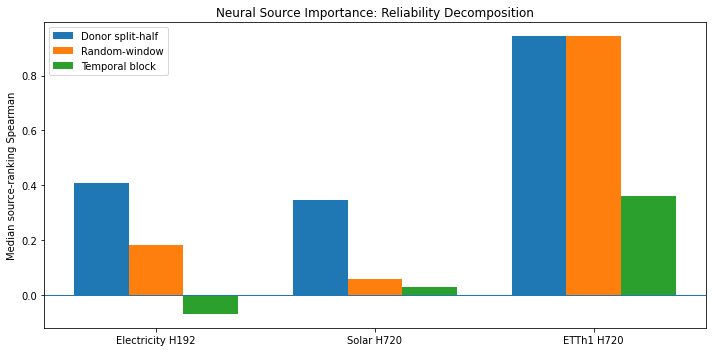

In [14]:
import matplotlib.pyplot as plt

labels = overview["dataset"] + " H" + overview["pred_len"].astype(str)
x = np.arange(len(overview))
w = .25

fig,ax = plt.subplots(figsize=(10,5))
ax.bar(x-w,overview["donor_split_half_rho"],w,label="Donor split-half")
ax.bar(x,overview["random_window_split_half_rho"],w,label="Random-window")
ax.bar(x+w,overview["temporal_block_rho"],w,label="Temporal block")
ax.axhline(0,linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Median source-ranking Spearman")
ax.set_title("Neural Source Importance: Reliability Decomposition")
ax.legend()
plt.tight_layout()
plt.show()

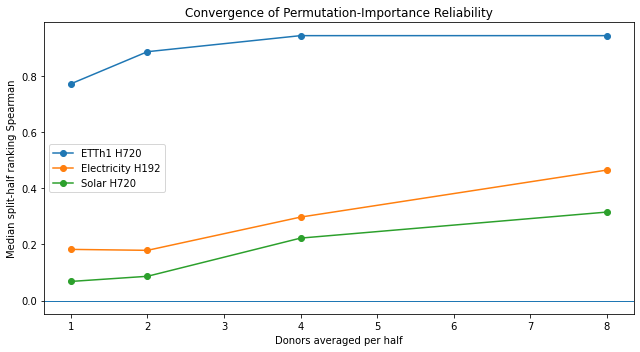

In [15]:
import matplotlib.pyplot as plt

fig,ax = plt.subplots(figsize=(9,5))
for (d,H),sub in count_summary.groupby(["dataset","pred_len"]):
    sub = sub.sort_values("donors_per_half")
    ax.plot(
        sub["donors_per_half"],
        sub["median_rho"],
        marker="o",
        label=f"{d} H{H}",
    )
ax.axhline(0,linewidth=1)
ax.set_xlabel("Donors averaged per half")
ax.set_ylabel("Median split-half ranking Spearman")
ax.set_title("Convergence of Permutation-Importance Reliability")
ax.legend()
plt.tight_layout()
plt.show()

## 12. Automatic conservative interpretation

In [16]:
print("="*94)
print("EXPECTED PERMUTATION IMPORTANCE — FINAL CHECK")
print("="*94)
display(overview.round(3))

a = alignment_summary[
    (alignment_summary["pool"]=="Extended")
    & (alignment_summary["metric"]=="endpoint_mse")
]
rho_P_EPI = float(a.iloc[0]["median_rho_P_EPI"]) if len(a)==1 else np.nan
rho_old_new = float(a.iloc[0]["median_rho_oldI_EPI"]) if len(a)==1 else np.nan

def fr(A,B):
    q = forecaster_summary[
        (forecaster_summary["metric"]=="endpoint_mse")
        & (forecaster_summary["A"]==A)
        & (forecaster_summary["B"]==B)
    ]
    return float(q.iloc[0]["median_rho"]) if len(q)==1 else np.nan

rho_R_M = fr("Ridge","MLP")
rho_R_I = fr("Ridge","iTransformer-EPI")
rho_M_I = fr("MLP","iTransformer-EPI")

print("\nStabilized endpoint alignment")
print(f"rho(P, EPI)            = {rho_P_EPI:+.3f}")
print(f"rho(old I, EPI)        = {rho_old_new:+.3f}")
print(f"rho(Ridge, MLP)        = {rho_R_M:+.3f}")
print(f"rho(Ridge, EPI)        = {rho_R_I:+.3f}")
print(f"rho(MLP, EPI)          = {rho_M_I:+.3f}")

donor_med = float(overview["donor_split_half_rho"].median())
window_med = float(overview["random_window_split_half_rho"].median())
temporal_med = float(overview["temporal_block_rho"].median())

print("\nMedian across representative conditions")
print(f"Donor split-half       = {donor_med:+.3f}")
print(f"Random-window split    = {window_med:+.3f}")
print(f"Temporal-block         = {temporal_med:+.3f}")

print("\nInterpretation")

if donor_med >= .60 and window_med >= .60:
    print("- EPI is sufficiently stable to donor choice and random test-window sampling.")
    if temporal_med < .40:
        print("- Temporal-block stability is much lower.")
        print("- This supports time/context-dependent functional source reliance rather than simple donor noise.")
    else:
        print("- Temporal-block ranking is also reasonably stable.")
        print("- A static expected source-importance ranking is defensible.")
elif donor_med >= .60:
    print("- Donor averaging stabilizes intervention noise, but source ranking remains sensitive to evaluated windows.")
    print("- Treat functional reliance as sample/context dependent.")
else:
    print("- Even 8-vs-8 donor halves remain unstable.")
    print("- Do not use pairwise EPI as a strong ground-truth ranking claim.")
    print("- Retain robust group-level cross-channel intervention results.")

if np.isfinite(rho_P_EPI) and abs(rho_P_EPI) < .30:
    print("- P vs neural reliance mismatch persists after EPI stabilization.")

if (
    (np.isfinite(rho_R_I) and rho_R_I < .30)
    or
    (np.isfinite(rho_M_I) and rho_M_I < .30)
):
    print("- Functional source reliance remains forecaster-dependent after stabilization.")

print("\nWording constraint")
print("Do NOT claim: predictive relevance itself is model-dependent.")
print("Use: controlled source utility does not necessarily transfer to forecaster-specific functional reliance.")

print("\nAfter this experiment, stop architecture/measurement expansion unless EPI reliability itself fails.")

EXPECTED PERMUTATION IMPORTANCE — FINAL CHECK


,dataset,pred_len,donor_split_half_rho,random_window_split_half_rho,temporal_block_rho
0,Electricity,192,0.409,0.184,-0.068
1,Solar,720,0.348,0.058,0.030
2,ETTh1,720,0.943,0.943,0.362



Stabilized endpoint alignment
rho(P, EPI)            = -0.164
rho(old I, EPI)        = +0.500
rho(Ridge, MLP)        = +0.254
rho(Ridge, EPI)        = +0.010
rho(MLP, EPI)          = +0.143

Median across representative conditions
Donor split-half       = +0.409
Random-window split    = +0.184
Temporal-block         = +0.030

Interpretation
- Even 8-vs-8 donor halves remain unstable.
- Do not use pairwise EPI as a strong ground-truth ranking claim.
- Retain robust group-level cross-channel intervention results.
- P vs neural reliance mismatch persists after EPI stabilization.
- Functional source reliance remains forecaster-dependent after stabilization.

Wording constraint
Do NOT claim: predictive relevance itself is model-dependent.
Use: controlled source utility does not necessarily transfer to forecaster-specific functional reliance.

After this experiment, stop architecture/measurement expansion unless EPI reliability itself fails.


## Paper decision guide

This section implements robustness and reliability checks for predictive utility and functional reliance under the fixed protocols reported in the paper.
